In [10]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

In [11]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.version)
print("Keras:", keras.version)

TensorFlow: <module 'tensorflow._api.v2.version' from 'd:\\Education\\Cellula\\EyeDisease\\EyeDisease\\.venv\\Lib\\site-packages\\tensorflow\\_api\\v2\\version\\__init__.py'>
Keras: <function version at 0x000001C6557E9D00>


In [3]:
BASE_DIR = Path(r"D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits")

TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"
TEST_DIR  = BASE_DIR / "test"

print("Train:", TRAIN_DIR.resolve())
print("Val  :", VAL_DIR.resolve())
print("Test :", TEST_DIR.resolve())

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert VAL_DIR.exists(), f"Validation folder not found: {VAL_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

Train: D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\train
Val  : D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\val
Test : D:\Education\Cellula\EyeDisease\EyeDisease\Data\dataset_splits\test


In [5]:
train_classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
val_classes   = sorted([p.name for p in VAL_DIR.iterdir() if p.is_dir()])
test_classes  = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Train classes:", train_classes)
print("Val classes:  ", val_classes)
print("Test classes: ", test_classes)

assert train_classes == val_classes == test_classes, "Class folders are inconsistent."

CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)

print("\nNumber of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Train classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Val classes:   ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Test classes:  ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']

Number of classes: 8
Classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [6]:
def count_images(split_dir):
    counts = {}
    valid_ext = {".jpg", ".png"}
    
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            counts[class_dir.name] = sum(
                1 for p in class_dir.iterdir()
                if p.is_file() and p.suffix.lower() in valid_ext
            )
    return pd.Series(counts, name=split_dir.name)

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

distribution = pd.concat([train_counts, val_counts, test_counts], axis=1).fillna(0).astype(int)

display(distribution)

,train,val,test
AMD,1000,41,41
Cataract,1200,51,51
Diabetic_Retinopathy,2879,617,617
Glaucoma,1500,139,140
Hypertension,700,13,13
Myopia,1000,44,44
Normal,3288,705,705
Others,1500,166,165


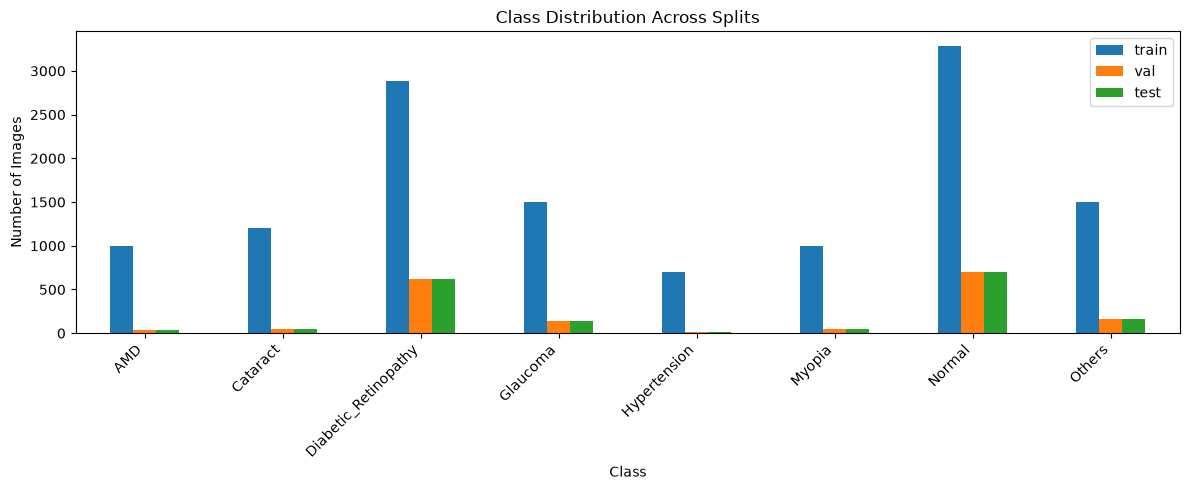

In [7]:
ax = distribution.plot(kind="bar", figsize=(12, 5))
ax.set_title("Class Distribution Across Splits")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
assert (distribution["train"] > 0).all()
assert (distribution["val"] > 0).all()
assert (distribution["test"] > 0).all()

print("Total train images:", distribution["train"].sum())
print("Total val images:  ", distribution["val"].sum())
print("Total test images: ", distribution["test"].sum())
print("Total images:      ", distribution.sum().sum())

Total train images: 13067
Total val images:   1776
Total test images:  1776
Total images:       16619


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 224
Batch size: 32


In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
TRAIN_DIR,
labels="inferred",
label_mode="int",
class_names=CLASS_NAMES,
image_size=(IMG_SIZE, IMG_SIZE),
batch_size=BATCH_SIZE,
shuffle=True,
seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
VAL_DIR,
labels="inferred",
label_mode="int",
class_names=CLASS_NAMES,
image_size=(IMG_SIZE, IMG_SIZE),
batch_size=BATCH_SIZE,
shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
TEST_DIR,
labels="inferred",
label_mode="int",
class_names=CLASS_NAMES,
image_size=(IMG_SIZE, IMG_SIZE),
batch_size=BATCH_SIZE,
shuffle=False
)

print("\nTensorFlow class mapping:")
print(train_ds.class_names)

assert train_ds.class_names == CLASS_NAMES
assert val_ds.class_names == CLASS_NAMES
assert test_ds.class_names == CLASS_NAMES

Found 13067 files belonging to 8 classes.
Found 1776 files belonging to 8 classes.
Found 1776 files belonging to 8 classes.

TensorFlow class mapping:
['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [13]:
normalization_layer = tf.keras.layers.Rescaling(
1.0 / 255.0
)

In [15]:
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):

    images = tf.cast(
        images,
        tf.float32
    )

    images = normalization_layer(
        images
    )

    return images, labels

In [16]:
train_ds = train_ds.map(
preprocess,
num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
preprocess,
num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
preprocess,
num_parallel_calls=AUTOTUNE
)

In [17]:
train_ds = train_ds.prefetch(
AUTOTUNE
)

val_ds = val_ds.prefetch(
AUTOTUNE
)

test_ds = test_ds.prefetch(
AUTOTUNE
)

print("TensorFlow input pipeline is ready.")

TensorFlow input pipeline is ready.


In [18]:
images, labels = next(
iter(train_ds)
)

print(
"Image batch shape:",
images.shape
)

print(
"Label batch shape:",
labels.shape
)

print(
"First labels:",
labels[:10].numpy().tolist()
)

print(
"Pixel minimum:",
float(tf.reduce_min(images))
)

print(
"Pixel maximum:",
float(tf.reduce_max(images))
)

assert images.shape[1:] == (
IMG_SIZE,
IMG_SIZE,
3
)

assert images.shape[0] <= BATCH_SIZE

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
First labels: [2, 0, 1, 0, 2, 6, 2, 6, 6, 2]
Pixel minimum: 0.0
Pixel maximum: 1.0


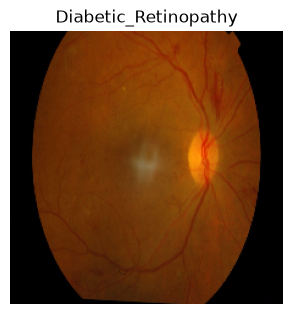

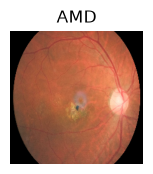

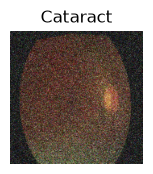

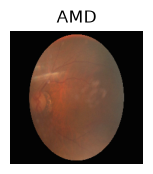

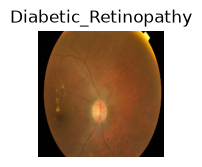

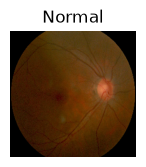

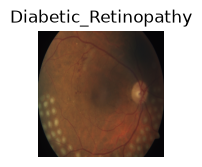

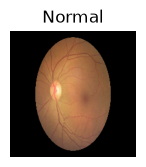

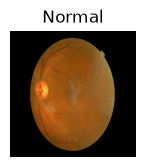

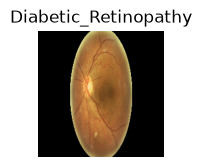

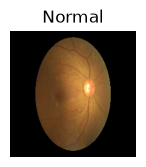

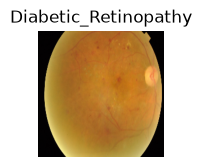

In [19]:
plt.figure(
figsize=(12, 9)
)

num_images = min(
12,
images.shape[0]
)

for i in range(num_images):

    ax = plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        images[i].numpy()
    )

    label = labels[i].numpy()

    plt.title(
        CLASS_NAMES[label]
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

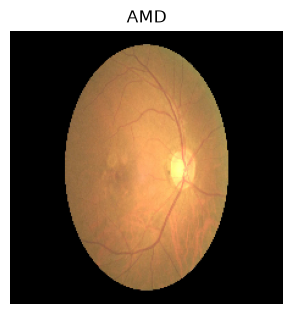

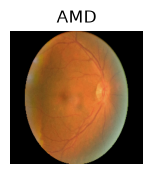

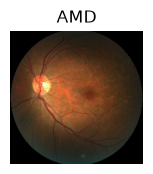

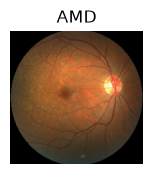

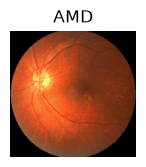

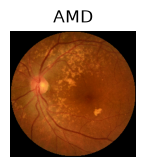

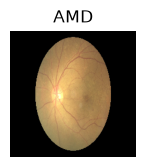

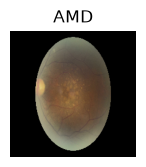

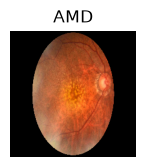

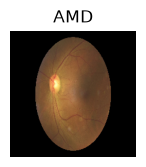

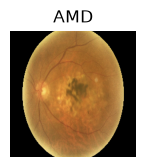

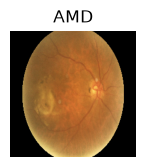

In [20]:
val_images, val_labels = next(
iter(val_ds)
)

plt.figure(
figsize=(12, 9)
)

num_images = min(
12,
val_images.shape[0]
)

for i in range(num_images):
    ax = plt.subplot(
        3,
        4,
        i + 1
    )

    plt.imshow(
        val_images[i].numpy()
    )

    label = val_labels[i].numpy()

    plt.title(
        CLASS_NAMES[label]
    )

    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [22]:

print(
"Classes:",
CLASS_NAMES
)

print(
"Number of classes:",
NUM_CLASSES
)

print(
"Image size:",
IMG_SIZE
)

print(
"Batch size:",
BATCH_SIZE
)

print(
"\nTrain images:",
distribution["train"].sum()
)

print(
"Validation images:",
distribution["val"].sum()
)

print(
"Test images:",
distribution["test"].sum()
)

print(
"\nOffline augmentation: ALREADY APPLIED"
)

print(
"Additional augmentation: DISABLED"
)

print(
"Normalization: ENABLED"
)

print(
"\nReady for Custom CNN.")

Classes: ['AMD', 'Cataract', 'Diabetic_Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']
Number of classes: 8
Image size: 224
Batch size: 32

Train images: 13067
Validation images: 1776
Test images: 1776

Offline augmentation: ALREADY APPLIED
Additional augmentation: DISABLED
Normalization: ENABLED

Ready for Custom CNN.
